# Suo

In [1]:
# working_directory = "/Users/kemalinecik/git_nosync/sctram"
working_directory = "/home/icb/kemal.inecik/work/codes/sctram"

In [2]:
import sys
sys.path.append(working_directory)

import logging
import gc
import os
import numpy as np
import pandas as pd
import networkx as nx
import scanpy as sc
import anndata as ad

sc.settings.verbose = 3

In [3]:
from sctram.generate.real import available_datasets
available_datasets()

Dataset Name: norman_sciplex_cpa
Description: Sciplex dose response dataset from Norman et al.
Filename: norman_sciplex_cpa.h5ad

Dataset Name: suo_developmental_complete
Description: Suo Developmental Complete single-cell RNA-seq dataset.
Filename: suo_developmental_complete.h5ad

Dataset Name: miller_developmental_complete
Description: Miller Developmental Complete single-cell RNA-seq dataset.
Filename: miller_developmental_complete.h5ad

Dataset Name: braun_developmental_complete
Description: Braun Developmental Complete single-cell RNA-seq dataset.
Filename: braun_developmental_complete.h5ad

Dataset Name: garcia_developmental_complete
Description: Garcia Developmental Complete single-cell RNA-seq dataset.
Filename: garcia_developmental_complete.h5ad

Dataset Name: he_developmental_complete
Description: He Developmental Complete single-cell RNA-seq dataset.
Filename: he_developmental_complete.h5ad

Dataset Name: kanemaru_developmental_complete
Description: Kanemaru Developmental Co

In [4]:
from sctram.generate.real import sc_suo_developmental_complete
from sctram.api._lower_level import TrajectoryEvaluationAPI
from sctram.input import read_dict

2025-02-15 21:34:43.097 | INFO     | sctram.api._defaults_read:load_default_metrics:23 - Loaded default metrics from /home/icb/kemal.inecik/work/codes/sctram/sctram/api/_defaults.yaml


2025-02-15 21:34:43.098 | INFO     | sctram.api._defaults_read:load_default_metrics:79 - Default metrics YAML structure validated successfully.


In [5]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

import pickle

import matplotlib.pyplot as plt
import seaborn as sns

_rcparams_path = os.path.join(working_directory, "reproducibility/figure_rcparams/rcparams.pickle")
with open(_rcparams_path, "rb") as file:
    _rcparams = pickle.load(file)
plt.rcParams.update(_rcparams)

In [6]:
dataset_dir = "/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data"
adata_suo = sc_suo_developmental_complete(dataset_dir=dataset_dir)
adata = adata_suo[adata_suo.obs["LVL0"] == "Haematopoeitic_lineage"]

2025-02-15 21:34:46.088 | WARNING  | sctram.generate.real._download:download_dataset:105 - File PosixPath('/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data/suo_developmental_complete.h5ad') already exists. Skipping download.


In [7]:
# sc.pp.neighbors(adata, use_rep='scvi', key_added='neighbors_scvi', n_neighbors=15)
# sc.tl.umap(adata, neighbors_key='neighbors_scvi')

In [8]:
adata_file_name_with_umap = os.path.join(dataset_dir, "suo_with_umap.h5ad")

In [9]:
# adata.obsm["X_umap_scvi"] = adata.obsm["X_umap"].copy()
# del adata.obsm["X_umap"]

In [10]:
# adata.write_h5ad(adata_file_name_with_umap)
adata = ad.read_h5ad(adata_file_name_with_umap)

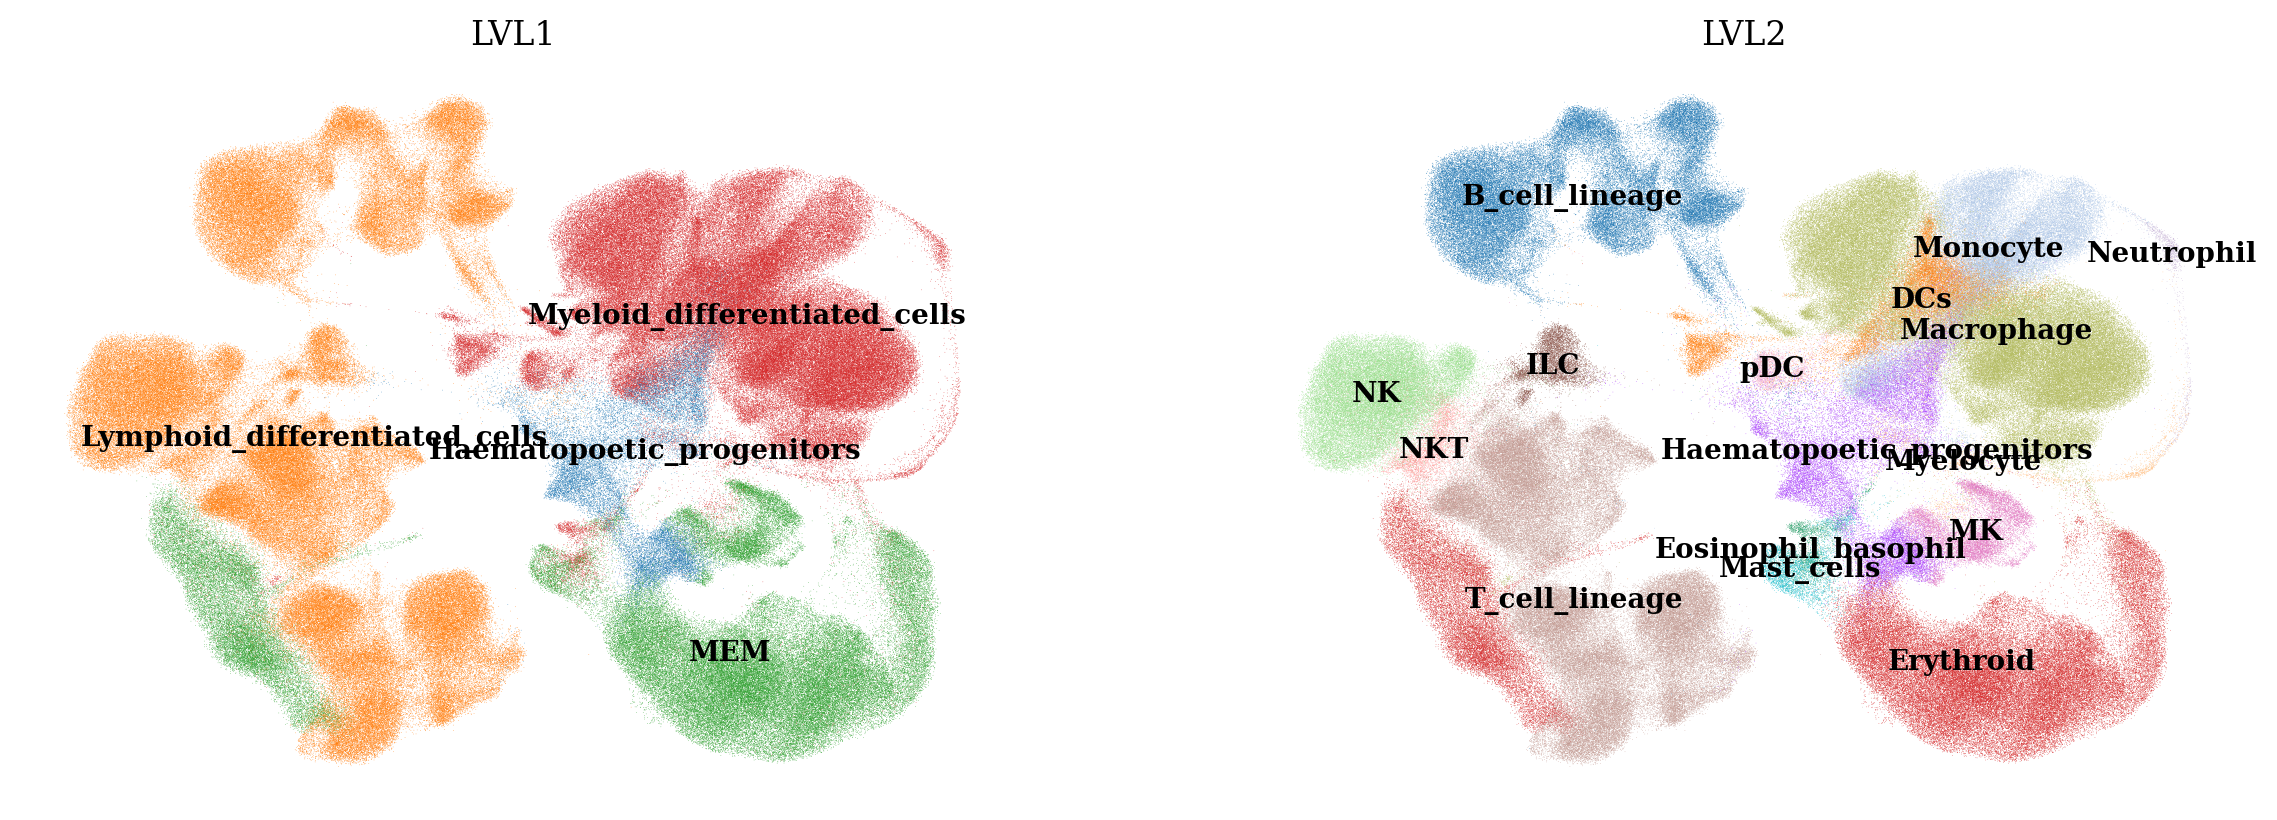

In [11]:
sc.pl.embedding(
    adata,
    basis='X_umap_scvi',
    color=['LVL1', 'LVL2'],
    frameon=False,
    legend_loc='on data',
)

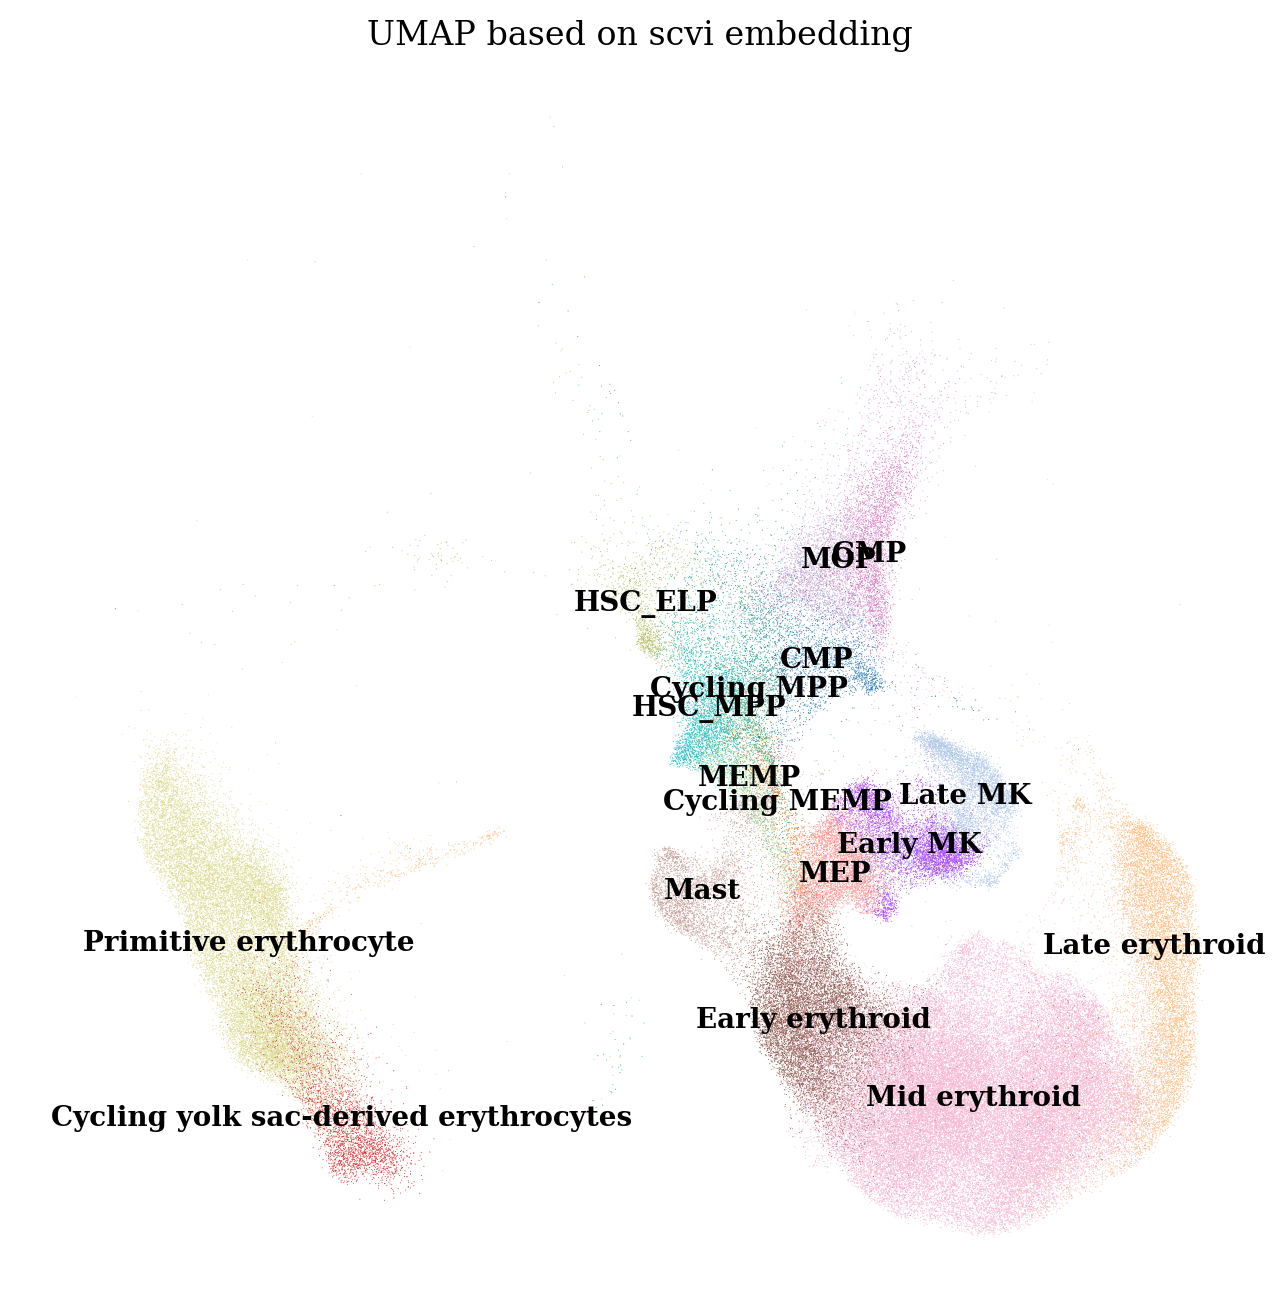

In [12]:
adata_mem = adata[adata.obs["LVL1"].isin(["MEM", "Haematopoetic_progenitors"])].copy()
fig, ax = plt.subplots(figsize=(8, 8))  # Set the size of the figure
sc.pl.embedding(
    adata_mem,
    basis='X_umap_scvi',
    color='LVL3',
    title='UMAP based on scvi embedding',
    show=False,
    legend_loc='on data',
    frameon=False,
    size=0.5,
    ax=ax
)
plt.show()

In [13]:
np.array(adata_mem.obs["LVL3"].unique())

array(['Early erythroid', 'MEMP', 'Early MK', 'Mast', 'GMP', 'HSC_ELP',
       'MOP', 'HSC_MPP', 'Mid erythroid', 'MEP', 'Cycling MEMP',
       'Cycling MPP', 'Late erythroid', 'Late MK', 'CMP',
       'Primitive erythrocyte', 'Cycling yolk sac-derived erythrocytes'],
      dtype=object)

## Calculate for MEP

In [14]:
ground_truth_trajectories = {
    "red_blood_cell": [
        ('MEMP', 'MEP'),
        ('MEP', 'Early erythroid'),
        ('Early erythroid', 'Mid erythroid'),
        ('Mid erythroid', 'Late erythroid'),
        ('MEP', 'Early MK'),
        ('Early MK', 'Late MK'),
    ],
}
input_trajectories_all = read_dict(ground_truth_trajectories)
input_trajectories = input_trajectories_all.get_trajectory("red_blood_cell", include_additional_nodes=False)

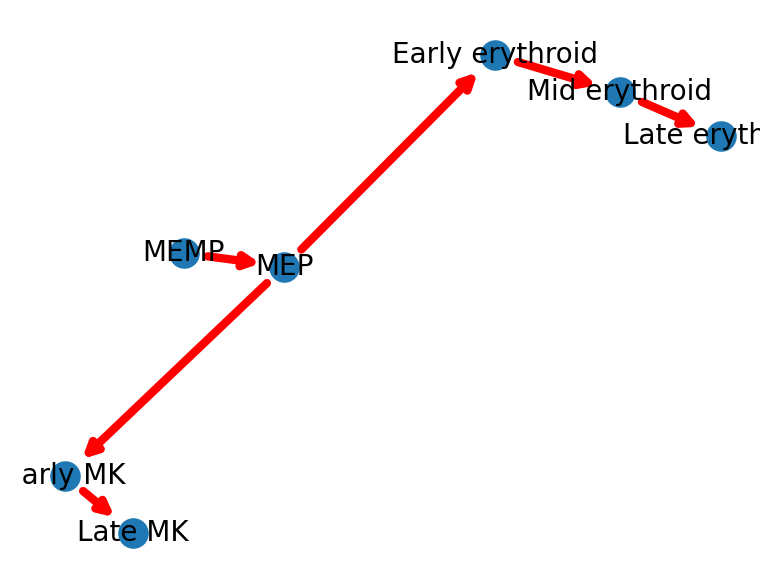

In [15]:
plt.figure(figsize=(4,3))
pos = nx.spring_layout(input_trajectories)  # positions for all nodes
nx.draw_networkx_nodes(input_trajectories, pos, node_size=100)
for u, v, data in input_trajectories.edges(data=True):
    nx.draw_networkx_edges(input_trajectories, pos, edgelist=[(u, v)], width=3, edge_color='red')
nx.draw_networkx_labels(input_trajectories, pos, font_size=10)
plt.axis("off")
plt.tight_layout()
plt.show()

In [16]:
adata

AnnData object with n_obs × n_vars = 561947 × 8192
    obs: 'sample_ID', 'organ', 'age', 'cell_type', 'sex', 'sex_inferred', 'concatenated_integration_covariates', 'integration_donor', 'integration_biological_unit', 'integration_sample_status', 'integration_library_platform_coarse', 'n_genes', '_scvi_batch', '_scvi_labels', 'LVL3', 'LVL2', 'LVL1', 'LVL0'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'neighbors_scvi', 'rank_genes_groups', 'umap', 'LVL1_colors', 'LVL2_colors'
    obsm: 'Unintegrated', 'X_pca', 'X_umap_scvi', 'harmony', 'invae', 'scanvi', 'scvi', 'tardis_1', 'tardis_2'
    obsp: 'neighbors_scvi_connectivities', 'neighbors_scvi_distances'

In [17]:
for obsm_key in ["scvi", "scanvi", "X_pca", "harmony", "invae", 'tardis_1', 'tardis_2']:
    print(f"\n\n\n############## {obsm_key!r} ##############\n\n\n")
    
    adata_obsm_key = ad.AnnData(
        X=adata.obsm[obsm_key].copy(),
        obs=adata.obs.copy(), 
    )
    ### # sc.pp.subsample(adata_obsm_key, fraction=0.01)
    display(adata_obsm_key)
    api_obsm_key = TrajectoryEvaluationAPI(
        adata=adata_obsm_key,  # only hematopoietic
        input_trajectories=input_trajectories,
        labels_obs="LVL3",
        root_label="MEMP",
        logger_level="DEBUG"
    )
    api_obsm_key.evaluate_with_defaults()
    df_obsm_key = api_obsm_key.get_all_results()
    df_obsm_key.to_pickle(os.path.join(dataset_dir, f"_metric_suo_{obsm_key}.pickle"))
    display(df_obsm_key)
    del adata_obsm_key, api_obsm_key, df_obsm_key
    gc.collect()




############## 'scvi' ##############





AnnData object with n_obs × n_vars = 561947 × 24
    obs: 'sample_ID', 'organ', 'age', 'cell_type', 'sex', 'sex_inferred', 'concatenated_integration_covariates', 'integration_donor', 'integration_biological_unit', 'integration_sample_status', 'integration_library_platform_coarse', 'n_genes', '_scvi_batch', '_scvi_labels', 'LVL3', 'LVL2', 'LVL1', 'LVL0'

2025-02-15 21:35:00.954 | INFO     | sctram.api._lower_level:evaluate_adjacency:154 - Starting adjacency evaluation.


2025-02-15 21:35:00.954 | INFO     | sctram.api._lower_level:_get_inference_method:79 - Running pseudotime inference with method 'PAGAInference'


2025-02-15 21:35:00.954 | INFO     | sctram.api._lower_level:_get_evaluate_method:72 - Running pseudotime evaluation with method 'AdjacencyMatrixEvaluation'


...

2025-02-16 23:55:18.834 | DEBUG    | sctram.evaluate._metricsmixin._spatialmetricsmixin:_calculate_spatial_autocorrelation:230 - 'Lisa' calculated for 'embedding'): 0.020200722275317058


2025-02-16 23:55:19.700 | DEBUG    | sctram.evaluate._metricsmixin._embeddingtrajectorymetricsmixin:_calculate:53 - Calculating metric: 'getis_ord_gi_star'


2025-02-17 00:06:43.634 | DEBUG    | sctram.evaluate._metricsmixin._spatialmetricsmixin:_calculate_spatial_autocorrelation:230 - 'Getis Ord Gi Star' calculated for 'embedding'): -0.21262915186297252


2025-02-17 00:06:43.843 | INFO     | sctram.evaluate._base:evaluate:202 - Evaluation completed successfully.


,path,metric,score
0,adjacency,frobenius,1.953275e+00
1,adjacency,L1,6.938897e+00
2,adjacency,accuracy,2.653061e-01
3,adjacency,graph_edit_distance,1.500000e+01
4,adjacency,spectral_distance,1.185317e+00
5,adjacency,jaccard,2.857143e-01
6,adjacency,hamming,3.600000e+01
7,adjacency,precision,1.000000e+00
8,adjacency,recall,5.000000e-01
9,adjacency,f1_score,6.666667e-01
